In [23]:
import pandas as pd
import seaborn as sns
import numpy as np

In [24]:
data = pd.read_csv("diabetic_data.csv", na_values=['?'], keep_default_na=False, low_memory=False)
data.head(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [25]:
print(data.shape)
data.info()
data.describe()

(101766, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [26]:
print("Unique patients:", data['patient_nbr'].nunique())
data['readmitted'].value_counts()

Unique patients: 71518


,count
readmitted,
NO,54864
>30,35545
<30,11357


In [27]:
missing = (data.isnull().mean() * 100).round(1).sort_values(ascending=False)
missing[missing > 0]

,0
weight,96.9
medical_specialty,49.1
payer_code,39.6
race,2.2
diag_3,1.4
diag_2,0.4


In [28]:
data['readmit_30'] = (data['readmitted'] == '<30').astype(int)
data.drop('readmitted', axis=1, inplace=True)
data['readmit_30'].value_counts()

,count
readmit_30,
0,90409
1,11357


In [29]:
end_of_life = [11,13,14,19,20,21]

#keep the rows whose code is NOT in the list

data = data[~data['discharge_disposition_id'].isin(end_of_life)].copy()
data.shape

(99343, 50)

In [30]:
#Fixing invalid gender

data = data[data['gender'] != 'Unknown/Invalid'].copy()
data.shape

(99340, 50)

In [32]:
data.drop(['encounter_id', 'weight','examide','citoglipton'], axis=1, inplace=True)

KeyError: "['encounter_id', 'weight', 'examide', 'citoglipton'] not found in axis"

In [33]:
#Fill missing values with Unknown

cols = ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
for col in cols:
    data[col] = data[col].fillna('Unknown')

In [34]:
#Renumber the rows after cleanup

data.reset_index(drop=True, inplace=True)
print("Final shape:", data.shape)
print("Patients:", data['patient_nbr'].unique())
print("Readmitted within 30 days (%):", round(data['readmit_30'].mean() * 100,1))
print("Remaining missing: ", data.isnull().sum().sum())

Final shape: (99340, 46)
Patients: [  8222157  55629189  86047875 ... 140199494 120975314 175429310]
Readmitted within 30 days (%): 11.4
Remaining missing:  0


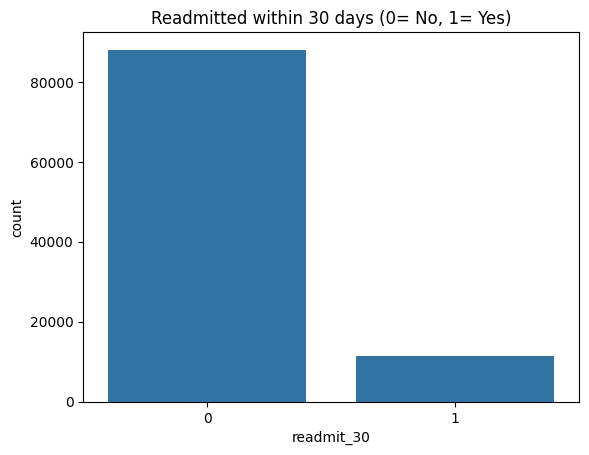

In [36]:
import matplotlib.pyplot as plt
sns.countplot(x='readmit_30', data=data)
plt.title('Readmitted within 30 days (0= No, 1= Yes)')
plt.show()

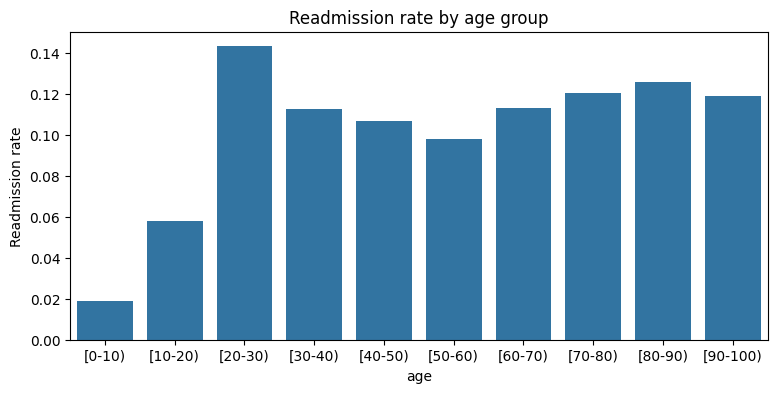

In [39]:
age = sorted(data['age'].unique())

plt.figure(figsize=(9,4))
sns.barplot(x='age', y='readmit_30', data=data, order= age, errorbar= None)
plt.title('Readmission rate by age group')
plt.ylabel('Readmission rate')

plt.show()


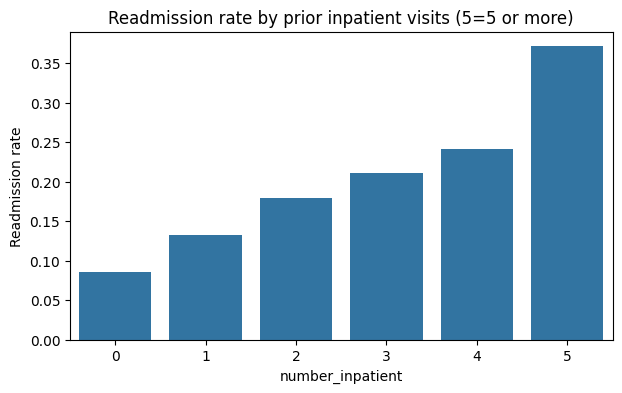

In [42]:
plt.figure(figsize=(7,4))
sns.barplot(x=data['number_inpatient'].clip(upper=5), y=data['readmit_30'], errorbar=None)
plt.title('Readmission rate by prior inpatient visits (5=5 or more)')
plt.xlabel('number_inpatient')
plt.ylabel('Readmission rate')
plt.show()

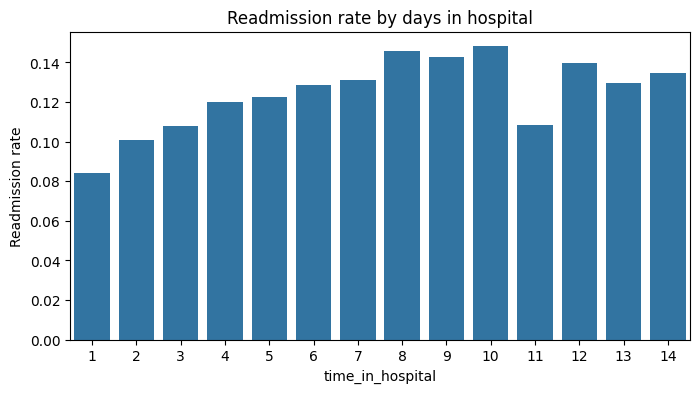

In [43]:
plt.figure(figsize=(8,4))
sns.barplot(x='time_in_hospital', y = 'readmit_30', data=data, errorbar= None)
plt.title('Readmission rate by days in hospital')
plt.ylabel('Readmission rate')
plt.show()

num_procedures       -0.011
number_outpatient     0.019
num_lab_procedures    0.024
num_medications       0.041
time_in_hospital      0.047
number_diagnoses      0.054
number_emergency      0.061
number_inpatient      0.168
Name: readmit_30, dtype: float64


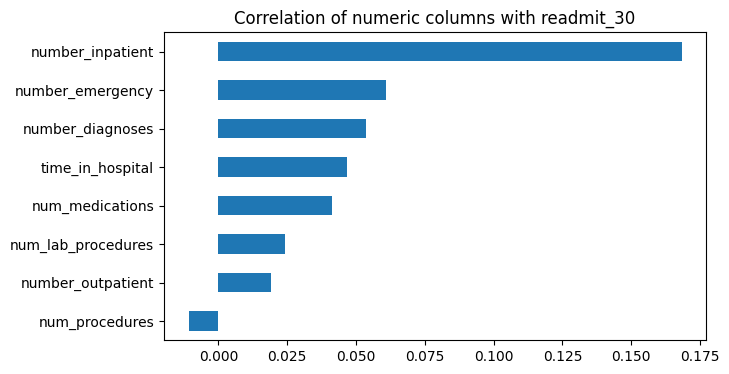

In [44]:
num = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

# Correlation of each numeric column with the target, sorted weakest to strongest
corr = data[num + ['readmit_30']].corr()['readmit_30'].drop('readmit_30').sort_values()
print(corr.round(3))

plt.figure(figsize=(7, 4))
corr.plot(kind='barh')
plt.title('Correlation of numeric columns with readmit_30')
plt.show()

In [45]:
age_map = {'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
           '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95}
data['age_num'] = data['age'].map(age_map)

print("Missing:", data['age_num'].isnull().sum())
data[['age', 'age_num']].head()

Missing: 0


,age,age_num
0,[0-10),5
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45


In [48]:
def group_diagnosis(code):
  code = str(code)
  if code == 'Unknown' or code.startswith('V') or code.startswith('E'):
    return 'Other'
  n = int(float(code))
  if n == 250:
    return 'Diabetes'
  elif 390 <=n <=459 or n == 785:
    return 'Circulatory'
  elif 460 <= n<= 519 or n == 786:
    return 'Respiratory'
  elif 520 <= n <= 579 or n == 787:
    return 'Digestive'
  elif 580 <= n <= 628 or n == 788:
    return 'Genitourinary'
  elif 800 <= n <= 999:
    return 'Injury'
  elif 710 <= n <= 739:
    return 'Musculoskeletal'
  elif 140 <= n <= 239:
        return 'Neoplasms'
  else:
        return 'Other'

In [49]:
for col in ['diag_1', 'diag_2', 'diag_3']:
  data[col + '_group'] = data[col].apply(group_diagnosis)

data['diag_1_group'].value_counts()

,count
diag_1_group,
Circulatory,29680
Other,17813
Respiratory,13934
Digestive,9333
Diabetes,8661
Injury,6851
Genitourinary,5002
Musculoskeletal,4935
Neoplasms,3131


In [50]:
total_prior = data['number_outpatient'] + data['number_emergency'] + data['number_inpatient']

print("number_inpatient  :", round(data['number_inpatient'].corr(data['readmit_30']), 3))
print("total prior visits:", round(total_prior.corr(data['readmit_30']), 3))

number_inpatient  : 0.168
total prior visits: 0.128


In [51]:
# The 21 diabetes medication columns hold 'No', 'Steady', 'Up' or 'Down'
medication_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

# n_med_changes = how many medications had their dose raised ('Up') or lowered ('Down')
data['n_med_changes'] = data[medication_cols].isin(['Up', 'Down']).sum(axis=1)
data['n_med_changes'].value_counts().sort_index()

,count
n_med_changes,
0,72320
1,25609
2,1299
3,107
4,5


In [52]:
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    data[col] = data[col].astype(str)

rare_cols = ['medical_specialty', 'payer_code', 'discharge_disposition_id', 'admission_source_id']
for col in rare_cols:
    top_values = data[col].value_counts().head(10).index
    data[col] = data[col].where(data[col].isin(top_values), 'Other')

data[rare_cols].nunique()

,0
medical_specialty,11
payer_code,11
discharge_disposition_id,11
admission_source_id,11


In [53]:
rare_medications = ['repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide',
             'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin',
             'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone',
             'metformin-pioglitazone']


data.drop(['age', 'diag_1', 'diag_2', 'diag_3'] + rare_medications, axis=1, inplace=True)

In [54]:
print("Shape:", data.shape)
print("Remaining missing:", data.isnull().sum().sum())
data.info()

Shape: (99340, 33)
Remaining missing: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99340 entries, 0 to 99339
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   patient_nbr               99340 non-null  int64 
 1   race                      99340 non-null  object
 2   gender                    99340 non-null  object
 3   admission_type_id         99340 non-null  object
 4   discharge_disposition_id  99340 non-null  object
 5   admission_source_id       99340 non-null  object
 6   time_in_hospital          99340 non-null  int64 
 7   payer_code                99340 non-null  object
 8   medical_specialty         99340 non-null  object
 9   num_lab_procedures        99340 non-null  int64 
 10  num_procedures            99340 non-null  int64 
 11  num_medications           99340 non-null  int64 
 12  number_outpatient         99340 non-null  int64 
 13  number_emergency          99340 non-

In [55]:
# ecnoding text columns and split by patient

cols = ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
        'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'glimepiride',
        'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change',
        'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group']


data_encoded = pd.get_dummies(data, columns=cols, drop_first=True, dtype=int)
data_encoded.shape

(99340, 118)

In [56]:
y = data_encoded['readmit_30']
groups = data_encoded['patient_nbr']

X = data_encoded.drop(['readmit_30', 'patient_nbr'], axis=1)
X.shape

(99340, 116)

In [57]:
from sklearn.model_selection import train_test_split

patients = groups.unique()

train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=0)

train_mask = groups.isin(train_patients)
test_mask = groups.isin(test_patients)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

In [58]:
print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])
print("Train patients:", groups[train_mask].nunique(), "| Test patients:", groups[test_mask].nunique())

# The key check: no patient should appear on both sides
print("Patients in both sets:", len(set(groups[train_mask]) & set(groups[test_mask])))

# The class imbalance should look similar on both sides
print("Train readmission rate (%):", round(y_train.mean() * 100, 1))
print("Test  readmission rate (%):", round(y_test.mean() * 100, 1))

Train rows: 79713 | Test rows: 19627
Train patients: 55989 | Test patients: 13998
Patients in both sets: 0
Train readmission rate (%): 11.5
Test  readmission rate (%): 10.8


In [59]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0)
print("Patients in both sets with a normal row split:", len(set(groups[X_tr.index]) & set(groups[X_te.index])))

Patients in both sets with a normal row split: 6697


In [60]:
X_train.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_num,n_med_changes,...,diag_2_group_Other,diag_2_group_Respiratory,diag_3_group_Diabetes,diag_3_group_Digestive,diag_3_group_Genitourinary,diag_3_group_Injury,diag_3_group_Musculoskeletal,diag_3_group_Neoplasms,diag_3_group_Other,diag_3_group_Respiratory
0,1,41,0,1,0,0,0,1,5,0,...,1,0,0,0,0,0,0,0,1,0
1,3,59,0,18,0,0,0,9,15,1,...,0,0,0,0,0,0,0,0,1,0
2,2,11,5,13,2,0,1,6,25,0,...,0,0,0,0,0,0,0,0,1,0
4,1,51,0,8,0,0,0,5,45,0,...,0,0,1,0,0,0,0,0,0,0
5,3,31,6,16,0,0,0,9,55,0,...,0,0,1,0,0,0,0,0,0,0


In [61]:
from sklearn.preprocessing import StandardScaler

num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses',
            'age_num', 'n_med_changes']

scaler = StandardScaler()

X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

X_train_processed[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_processed[num_cols] = scaler.transform(X_test[num_cols])

X_train_processed[num_cols].describe().round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_num,n_med_changes
count,79713.00,79713.00,79713.00,79713.00,79713.00,79713.00,79713.00,79713.00,79713.00,79713.00
mean,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.14,-2.14,-0.78,-1.85,-0.29,-0.21,-0.50,-3.29,-3.82,-0.59
25%,-0.80,-0.61,-0.78,-0.74,-0.29,-0.21,-0.50,-0.72,-0.68,-0.59
50%,-0.13,0.05,-0.20,-0.12,-0.29,-0.21,-0.50,0.31,-0.05,-0.59
75%,0.54,0.72,0.39,0.49,-0.29,-0.21,0.29,0.82,0.58,1.46
max,3.23,4.55,2.75,8.00,32.84,78.03,16.02,4.42,1.83,7.62


In [62]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=0)
model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=0)

In [64]:
y_pred = model.predict(X_test_processed)
y_pred_train = model.predict(X_train_processed)

y_prob = model.predict_proba(X_test_processed)[:,1]
y_prob_train = model.predict_proba(X_train_processed)[:,1]


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Train Accuracy:", round(accuracy_score(y_train, y_pred_train), 3))
print("Test  Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Test  Precision:", round(precision_score(y_test, y_pred, zero_division=0), 3))
print("Test  Recall:", round(recall_score(y_test, y_pred), 3))
print("Test  F1:", round(f1_score(y_test, y_pred), 3))
print("Train ROC-AUC:", round(roc_auc_score(y_train, y_prob_train), 3))
print("Test  ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

Train Accuracy: 0.885
Test  Accuracy: 0.892
Test  Precision: 0.5
Test  Recall: 0.014
Test  F1: 0.028
Train ROC-AUC: 0.668
Test  ROC-AUC: 0.66


In [66]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))
print("Predicted readmissions:", y_pred.sum(), "| Actual readmissions:", y_test.sum())

[[17480    30]
 [ 2087    30]]
Predicted readmissions: 60 | Actual readmissions: 2117


In [67]:
# Same model, but readmitted patients count for more during training
model_bal = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)
model_bal.fit(X_train_processed, y_train)

y_pred_bal = model_bal.predict(X_test_processed)
y_pred_train_bal = model_bal.predict(X_train_processed)
y_prob_bal = model_bal.predict_proba(X_test_processed)[:, 1]
y_prob_train_bal = model_bal.predict_proba(X_train_processed)[:, 1]

In [69]:
print("Balanced Train Accuracy:", round(accuracy_score(y_train, y_pred_train_bal), 3))
print("Balanced Test  Accuracy:", round(accuracy_score(y_test, y_pred_bal), 3))
print("Balanced Test  Precision:", round(precision_score(y_test, y_pred_bal, zero_division=0), 3))
print("Balanced Test  Recall:", round(recall_score(y_test, y_pred_bal), 3))
print("Balanced Test  F1:", round(f1_score(y_test, y_pred_bal), 3))
print("Balanced Train ROC-AUC:", round(roc_auc_score(y_train, y_prob_train_bal), 3))
print("Balanced Test  ROC-AUC:", round(roc_auc_score(y_test, y_prob_bal), 3))
print(confusion_matrix(y_test, y_pred_bal))

Balanced Train Accuracy: 0.668
Balanced Test  Accuracy: 0.67
Balanced Test  Precision: 0.172
Balanced Test  Recall: 0.538
Balanced Test  F1: 0.26
Balanced Train ROC-AUC: 0.67
Balanced Test  ROC-AUC: 0.661
[[12004  5506]
 [  977  1140]]


In [70]:
# Carve a validation set out of the TRAINING patients (again splitting patients, not rows)
fit_patients, val_patients = train_test_split(train_patients, test_size=0.2, random_state=0)

fit_mask = groups.isin(fit_patients)
val_mask = groups.isin(val_patients)

X_fit, y_fit = X[fit_mask], y[fit_mask]
X_val, y_val = X[val_mask], y[val_mask]

print("Fit rows:", X_fit.shape[0], "| Validation rows:", X_val.shape[0])
print("Patients in both:", len(set(groups[fit_mask]) & set(groups[val_mask])))

Fit rows: 63817 | Validation rows: 15896
Patients in both: 0


In [71]:
from lightgbm import LGBMClassifier

val_auc = {}

for n in [50,100,200,300,500]:
  m = LGBMClassifier(n_estimators=n, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                       subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                       random_state=0, verbose=-1)
  m.fit(X_fit, y_fit)
  val_auc[n] = roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
  print(n, "trees -> Validation ROC-AUC:", round(val_auc[n], 4))

# The number of trees with the highest validation score
best_n = max(val_auc, key=val_auc.get)
print("Best number of trees:", best_n)

50 trees -> Validation ROC-AUC: 0.6625
100 trees -> Validation ROC-AUC: 0.6665
200 trees -> Validation ROC-AUC: 0.6701
300 trees -> Validation ROC-AUC: 0.6706
500 trees -> Validation ROC-AUC: 0.6659
Best number of trees: 300


In [72]:
# Refit on the FULL training set using the best number of trees
lgbm_model = LGBMClassifier(n_estimators=best_n, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                            subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                            random_state=0, verbose=-1)
lgbm_model.fit(X_train, y_train)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, min_child_samples=50,
               n_estimators=300, random_state=0, subsample=0.8,
               subsample_freq=1, verbose=-1)

In [73]:
y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_train_lgbm = lgbm_model.predict(X_train)

y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
y_prob_train_lgbm = lgbm_model.predict_proba(X_train)[:, 1]

In [74]:
print("LightGBM Train Accuracy:", round(accuracy_score(y_train, y_pred_train_lgbm), 3))
print("LightGBM Test  Accuracy:", round(accuracy_score(y_test, y_pred_lgbm), 3))
print("LightGBM Train ROC-AUC:", round(roc_auc_score(y_train, y_prob_train_lgbm), 3))
print("LightGBM Test  ROC-AUC:", round(roc_auc_score(y_test, y_prob_lgbm), 3))
print()
print("Logistic Regression Test ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("LightGBM            Test ROC-AUC:", round(roc_auc_score(y_test, y_prob_lgbm), 3))

LightGBM Train Accuracy: 0.888
LightGBM Test  Accuracy: 0.893
LightGBM Train ROC-AUC: 0.778
LightGBM Test  ROC-AUC: 0.675

Logistic Regression Test ROC-AUC: 0.66
LightGBM            Test ROC-AUC: 0.675


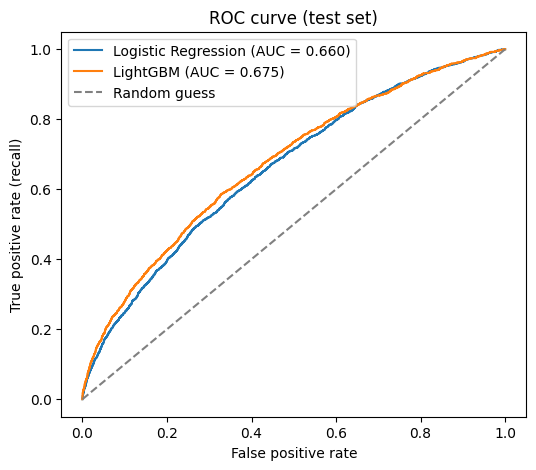

In [75]:
from sklearn.metrics import roc_curve

# Points of the ROC curve for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {roc_auc_score(y_test, y_prob_lgbm):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate (recall)')
plt.title('ROC curve (test set)')
plt.legend()
plt.show()

Average precision - Logistic Regression: 0.205
Average precision - LightGBM: 0.231
Random guess (base rate): 0.108


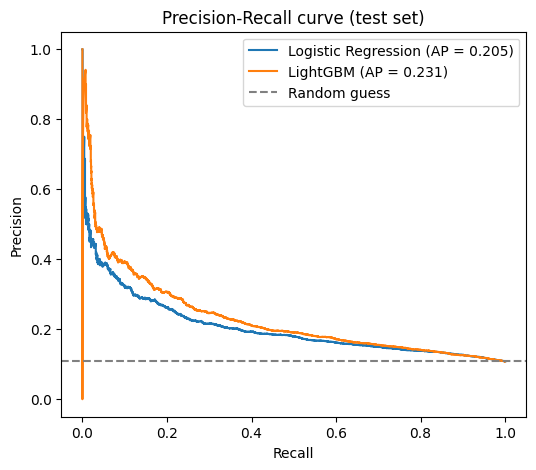

In [76]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob)
prec_lgbm, rec_lgbm, _ = precision_recall_curve(y_test, y_prob_lgbm)

ap_lr = average_precision_score(y_test, y_prob)
ap_lgbm = average_precision_score(y_test, y_prob_lgbm)
print("Average precision - Logistic Regression:", round(ap_lr, 3))
print("Average precision - LightGBM:", round(ap_lgbm, 3))
print("Random guess (base rate):", round(y_test.mean(), 3))

plt.figure(figsize=(6, 5))
plt.plot(rec_lr, prec_lr, label=f'Logistic Regression (AP = {ap_lr:.3f})')
plt.plot(rec_lgbm, prec_lgbm, label=f'LightGBM (AP = {ap_lgbm:.3f})')
plt.axhline(y_test.mean(), linestyle='--', color='gray', label='Random guess')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve (test set)')
plt.legend()
plt.show()

In [77]:
import numpy as np

# "If we flag only the riskiest 10%, 20% or 30% of patients, what do we catch?"
rows = []
for pct in [10, 20, 30]:
    for name, prob in [('Logistic Regression', y_prob), ('LightGBM', y_prob_lgbm)]:
        cut = np.percentile(prob, 100 - pct)       # risk score that separates the top pct% from the rest
        flag = prob >= cut                          # True for the flagged patients
        precision = y_test[flag].mean()             # share of flagged patients really readmitted
        recall = y_test[flag].sum() / y_test.sum()  # share of all readmissions we caught
        lift = precision / y_test.mean()            # how many times better than random picking
        rows.append([name, pct, flag.sum(), precision, recall, lift])

capture_table = pd.DataFrame(rows, columns=['Model', 'Top % flagged', 'Patients flagged', 'Precision', 'Recall', 'Lift'])
capture_table.round(3)

,Model,Top % flagged,Patients flagged,Precision,Recall,Lift
0,Logistic Regression,10,1963,0.244,0.226,2.258
1,LightGBM,10,1963,0.269,0.250,2.498
2,Logistic Regression,20,3926,0.199,0.369,1.847
3,LightGBM,20,3926,0.213,0.396,1.979
4,Logistic Regression,30,5888,0.180,0.499,1.664
5,LightGBM,30,5888,0.188,0.522,1.740


In [78]:
# A model trained ONLY on the fitting part, so the validation scores are honest
lgbm_fit = LGBMClassifier(n_estimators=best_n, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                          random_state=0, verbose=-1)
lgbm_fit.fit(X_fit, y_fit)
y_prob_val = lgbm_fit.predict_proba(X_val)[:, 1]

# Cutoff = 80th percentile of validation risk scores = "flag the top 20%"
cutoff = np.percentile(y_prob_val, 80)
print("Cutoff:", round(cutoff, 3))

Cutoff: 0.157


In [79]:
from sklearn.metrics import classification_report

# Apply the fixed cutoff to the test set, once
y_flag = (y_prob_lgbm >= cutoff).astype(int)

print("Share of test patients flagged (%):", round(y_flag.mean() * 100, 1))
print("Precision:", round(precision_score(y_test, y_flag), 3))
print("Recall:", round(recall_score(y_test, y_flag), 3))
print("F1:", round(f1_score(y_test, y_flag), 3))
print(confusion_matrix(y_test, y_flag))
print(classification_report(y_test, y_flag))

Share of test patients flagged (%): 18.8
Precision: 0.219
Recall: 0.381
F1: 0.278
[[14633  2877]
 [ 1311   806]]
              precision    recall  f1-score   support

           0       0.92      0.84      0.87     17510
           1       0.22      0.38      0.28      2117

    accuracy                           0.79     19627
   macro avg       0.57      0.61      0.58     19627
weighted avg       0.84      0.79      0.81     19627



In [80]:
import shap

In [81]:
explainer = shap.TreeExplainer(lgbm_model)
X_sample = X_test.sample(3000, random_state=0)
shap_values = explainer(X_sample)
if len(shap_values.shape) == 3:
  shap_values = shap_values[:,:,1]
shap_values.shape

(3000, 116)

In [82]:
# Average size of each feature's push on the prediction (ignoring direction)
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance = pd.Series(mean_abs_shap, index=X_sample.columns).sort_values(ascending=False)
importance.head(12).round(3)

,0
number_inpatient,0.288
discharge_disposition_id_3,0.107
number_diagnoses,0.070
age_num,0.066
time_in_hospital,0.063
payer_code_Unknown,0.056
diabetesMed_Yes,0.054
number_emergency,0.048
num_medications,0.048
discharge_disposition_id_22,0.046


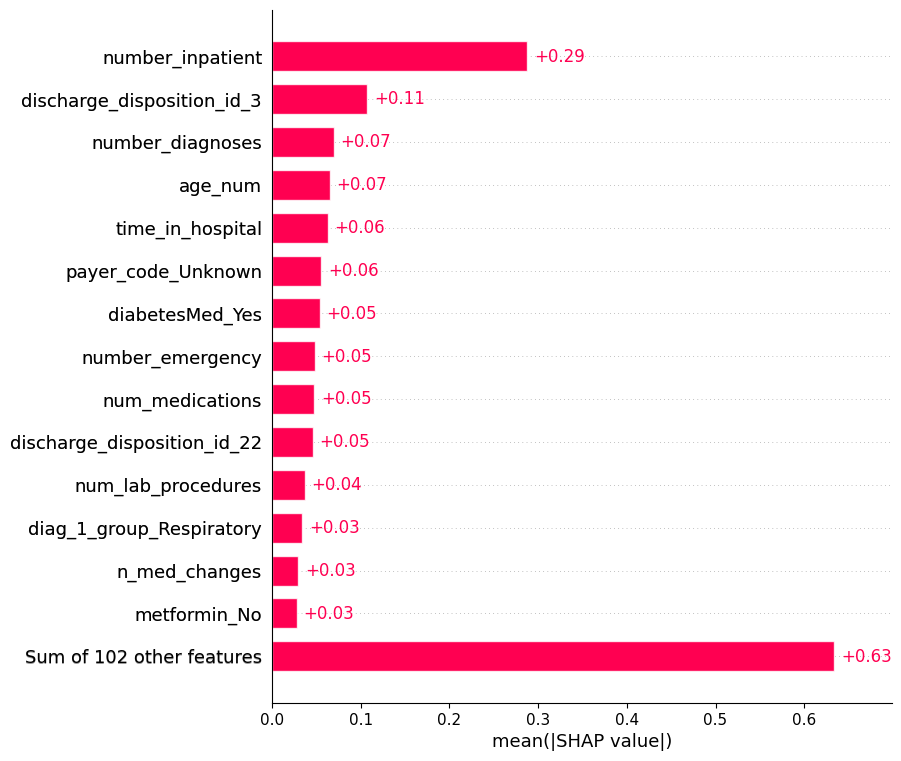

In [85]:
shap.plots.bar(shap_values, max_display=15)

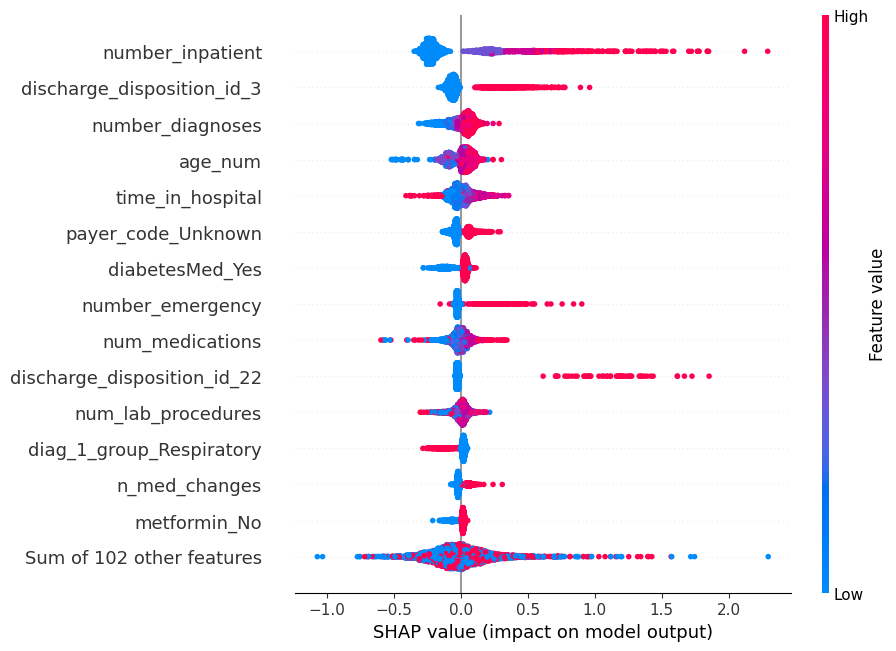

In [86]:
shap.plots.beeswarm(shap_values, max_display=15)

Highest-risk patient - predicted risk: 0.714
Lowest-risk patient  - predicted risk: 0.019


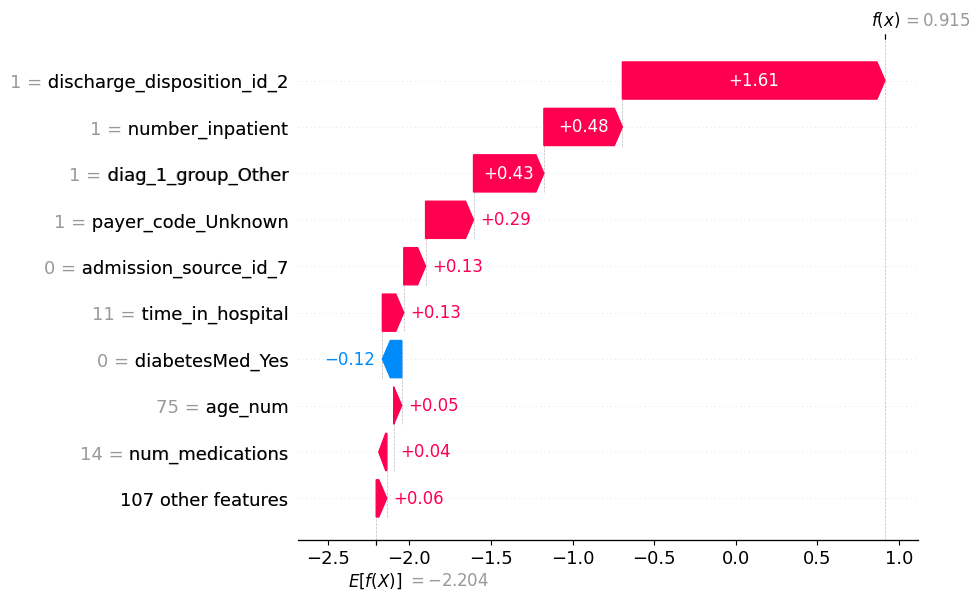

In [87]:
# The highest-risk and lowest-risk patients in the sample
probs_sample = lgbm_model.predict_proba(X_sample)[:, 1]
high_idx = int(probs_sample.argmax())
low_idx = int(probs_sample.argmin())

print("Highest-risk patient - predicted risk:", round(probs_sample[high_idx], 3))
print("Lowest-risk patient  - predicted risk:", round(probs_sample[low_idx], 3))

# Why did the model give this patient such a high score?
shap.plots.waterfall(shap_values[high_idx], max_display=10)

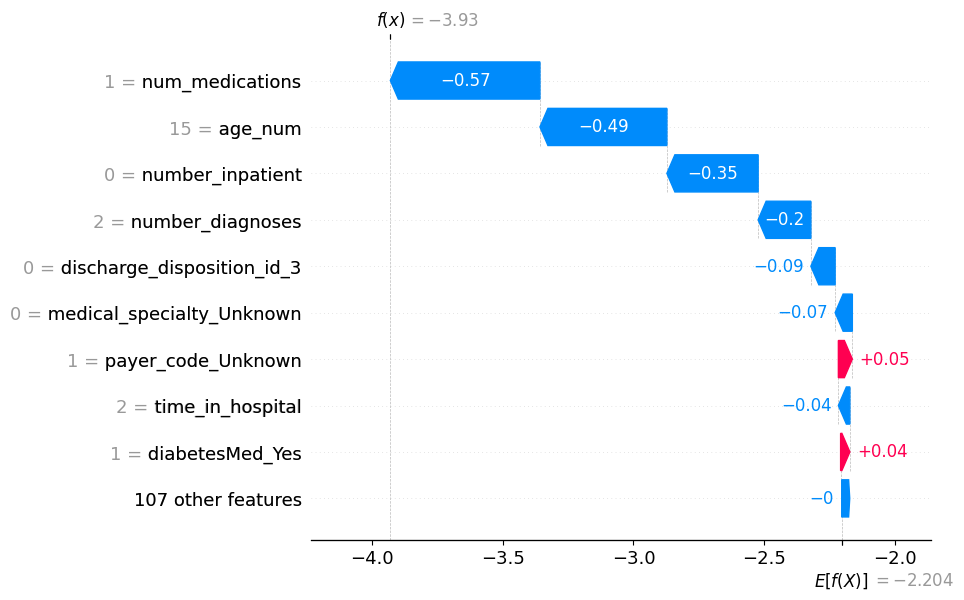

In [88]:
# And why such a low score for this one?
shap.plots.waterfall(shap_values[low_idx], max_display=10)